---
title: Introduction to Gradient Descent
author: Mark Fuge
format:
    html:
        code-fold: true
---

We will now review Linear Regression from the standpoint of Gradient Descent (instead of the normal equations), so as to build our intuition about how Gradient Descent works, and also introduce the concept of Stochastic Gradient Descent (SGD).

Let's first set up our notation for the problem:
$$
y = w\cdot x + b + \epsilon
$$
Or, if we consider $x = [1, x]$ then:
$$
y = \mathbf{w^T\cdot x} + \epsilon
$$

**Learning Objectives**

By the end of this chapter, you should be able to:

1. Derive the gradient of the mean squared error for a linear model and write down the gradient descent update.
2. Relate the step size (learning rate) to convergence, oscillation and divergence.
3. Contrast batch gradient descent with stochastic and mini-batch gradient descent, including decaying step sizes and the Robbins-Monro conditions.
4. Map a hand-coded gradient descent loop onto a library implementation and its hyperparameters.
5. Explain, at a conceptual level, what momentum does, how batch size trades noise for cost, and why normalizing features makes gradient descent converge faster.

Coefficient: 42.38


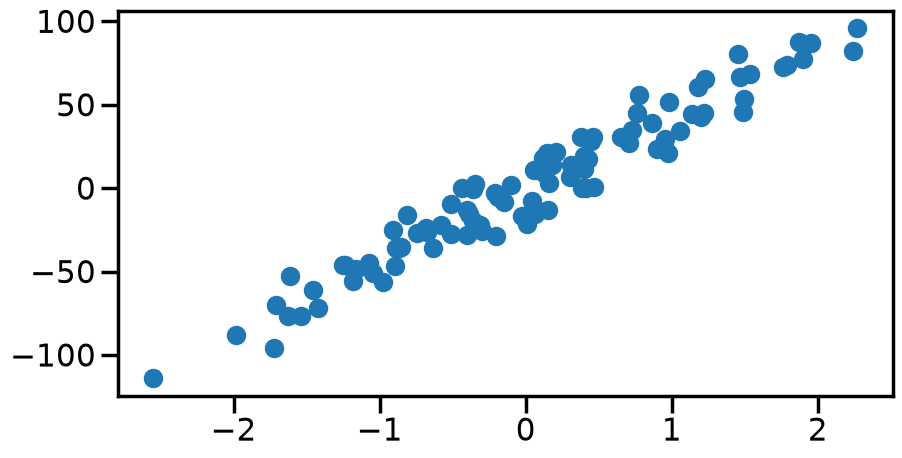

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_regression
sns.set_context('poster')


n_samples = 100   # How many datapoints do we want?

X, y, coef = make_regression(n_samples=n_samples, # How many data?
                               n_features=1,    # How many dimensions?
                               n_informative=1, # How many dimensions matter?
                               noise=10,   # Add noise to the line
                               coef=True,  # Return the coefficients for us
                               random_state=0)  # Same random numbers every time

print("Coefficient: {:.5s}".format(str(coef)))
plt.figure(figsize=(10,5))
plt.scatter(X,y)
plt.show()

One thing to notice about this dataset before we go on: `make_regression` produces data centred on the origin, so the true line passes through zero and there is no intercept to learn. The chapter therefore fits a single parameter, the slope $w$, which keeps every plot one-dimensional. The intercept returns in the Normalization section at the end of the chapter, where having two parameters is exactly the point.

From your earlier statistics classes, you likely learned how to solve for the linear regression weights using the [Normal Equations](https://en.wikipedia.org/wiki/Linear_least_squares_%28mathematics%29#Derivation_of_the_normal_equations):
$$
\hat{w} = (X^T X)^{-1}X^T y
$$

In [2]:
X = np.matrix(X)
y = np.matrix(y).T
wn = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
wn = wn[0,0]
print(wn)

42.57166255883968


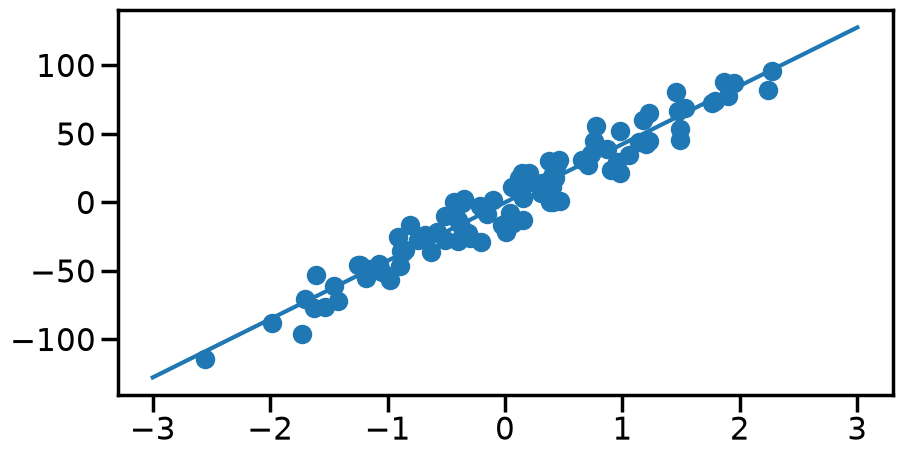

In [3]:
plt.figure(figsize=(10,5))
plt.scatter(np.asarray(X).ravel(),np.asarray(y).ravel())
plt.plot([-3,3],[-3*wn, 3*wn])
plt.show()

There are ways of solving the normal equations directly without needing to take the inverse (such as using the [Cholesky decomposition](https://en.wikipedia.org/wiki/Cholesky_decomposition)), however today we are going to focus on a different kind of solver that has more broader applications: [Gradient Descent](https://en.wikipedia.org/wiki/Gradient_descent) and it's cousin [Stochastic Gradient Descent (SGD)](https://en.wikipedia.org/wiki/Stochastic_gradient_descent).

We first need to start with some sort of Cost function that we wish to minimize. In general, we will consider costs of the form:
$$
Loss = Error + \alpha\cdot Penalty
$$

Specifically for Linear Models, we will talk about costs (which I'll call $J$) of the form:

$$
J(w,X) = \frac{1}{N}\Sigma_{i=1}^N \left(\mathbf{y}_i - f(\mathbf{w},\mathbf{x}_i)\right)^2 + \alpha\cdot\Omega(\mathbf{w})
$$

where for Linear Models $f(w,X) = \mathbf{w\cdot X}$, so that our overall cost becomes:

$$
J(w,X) = \frac{1}{N}\Sigma_{i=1}^N \left(\mathbf{y}_i - \mathbf{w\cdot \mathbf{x}_i}\right)^2 + \alpha\cdot\Omega(\mathbf{w})
$$

We'll consider the no-penalty case ($\alpha=0$), so that our loss is just:

$$
J(w,X) = \frac{1}{N}\Sigma_{i=1}^N \left(\mathbf{y}_i - \mathbf{w\cdot \mathbf{x}_i}\right)^2
$$

Let's plot this cost as a function of the line slope, just to get an idea of what it looks like:

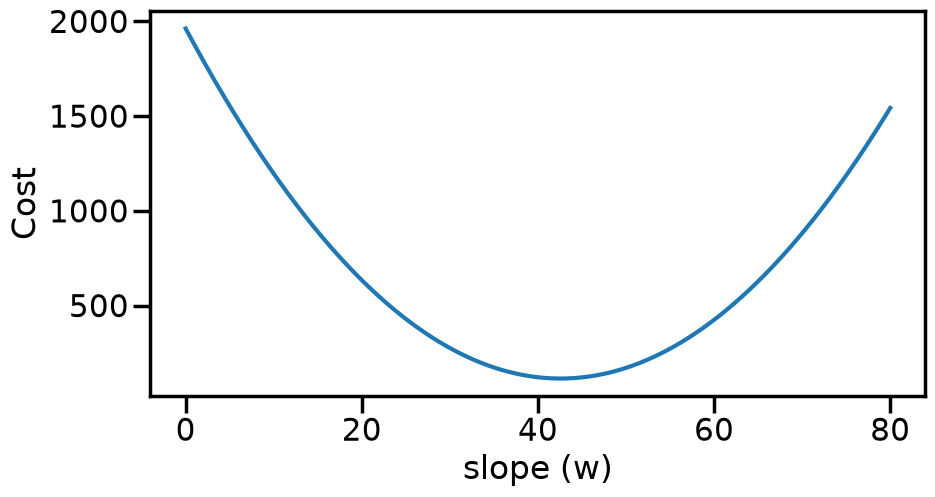

In [4]:
def loss(w):
    N = len(y)
    return np.sum(np.square(y-w*X))/N

wp = np.linspace(0,80,1000)
cost = [loss(w) for w in wp]
plt.figure(figsize=(10,5))
plt.plot(wp,cost)
plt.ylabel('Cost')
plt.xlabel('slope (w)')
plt.show()

While it might seem clear to us, visually, where the lowest cost is, actually finding this point automatically via a computer with minimal effort is another story. This is essentially what the field of Optimization tries to do. One simple (but powerful) method of optimization is Gradient Descent. It works by taking a (possibly random) starting point (e.g., w=60), and then computing the gradient of the function at that point. Since gradients will point upwards, and we want to minimize the cost, we will instead walk in the *negative* gradient direction, which should move us closer to the bottom. Let's see this on an example, by computing the gradient of our cost function above with respect to the slope (w):

$$
\begin{aligned}
\frac{\partial J}{\partial w} &=& \frac{\partial}{\partial w} \left( \frac{1}{N}\Sigma_{i=1}^N \left(\mathbf{y}_i - \mathbf{w}\cdot \mathbf{x}_i\right)^2 \right) \\
&=&\frac{1}{N}\Sigma_{i=1}^N  \frac{\partial}{\partial w} \left(\left(\mathbf{y}_i - \mathbf{w}\cdot \mathbf{x}_i\right)^2 \right) \\
&=&\frac{2}{N}\Sigma_{i=1}^N (\mathbf{y}_i - \mathbf{w}\cdot \mathbf{x}_i) \frac{\partial}{\partial w} \left(\mathbf{y}_i - \mathbf{w}\cdot \mathbf{x}_i \right) \\
&=&-\frac{2}{N}\Sigma_{i=1}^N (\mathbf{y}_i - \mathbf{w}\cdot \mathbf{x}_i) \cdot \mathbf{x}_i 
\end{aligned}
$$

Let's plot this:

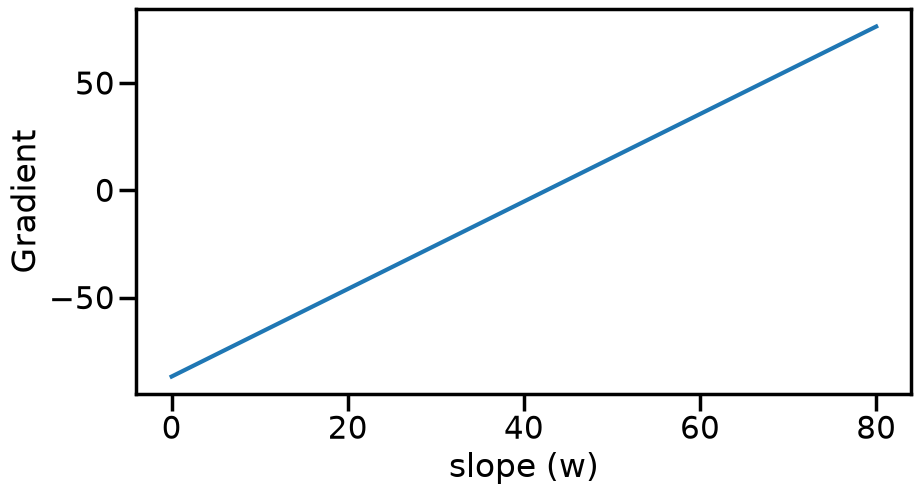

In [5]:
def dloss(w,X):
    N = len(y)
    return -2*np.sum(np.multiply(y-w*X,X))/N

grad = [dloss(w,X) for w in wp]
plt.figure(figsize=(10,5))
plt.plot(wp,grad)
plt.ylabel('Gradient')
plt.xlabel('slope (w)')
plt.show()

Once we have 1) a starting point, and 2) the gradient at a point, the idea with gradient descent is to take a small step ($\alpha$) in the direction of the negative gradient:

$$
w_{t+1} = w_t - \alpha \frac{\partial J}{\partial w}
$$

Note: here we are just considering a single parameter (the slope, w), but this method extends to multiple parameters ($\mathbf{w}$), via the gradient operator:

$$
\mathbf{w}_{t+1} = \mathbf{w}_t - \alpha \nabla_\mathbf{w} J
$$

One more thing worth noting before we start walking downhill: the squared-error cost above, and every loss and penalty we met in the previous chapter, is *convex* in the weights. That means there is a single valley with one bottom, so gradient descent (and the stochastic variant we meet below) cannot get stuck somewhere else. This convenient property is what we lose once we move to neural networks in Part 2.

In [6]:
def grad_step(w, X, alpha):
    return w - alpha*dloss(w,X)

In [7]:
wg = 50  # Start at 50
wg = grad_step(wg, X, 0.1)  # Take a small step
print(wg)  # Now we are at...

48.4855051874447


::: {.callout-tip appearance="default"}
### Experiment: Starting Point and Step Size
Try modifying the initial guess `wg` and the step size `alpha` in the cell below and re-running the cells that follow. What do you observe?

- Does the starting point change where you end up, or only how long it takes?
- What happens for a very small step size? For a very large one?
:::

In [8]:
######################
# Try changing the below
wg = 80 # Initial guess at slope; Try changing this
alpha = 0.1  # Try changing alpha (both big and small)
# What do you notice?
###########################


In [9]:

num_steps = 20 # Take 20 steps
weights = np.zeros(num_steps)
weights[0] = wg  # Set the initial weight
for i in range(1,num_steps): 
    weights[i] = grad_step(weights[i-1], X, alpha)
print("Final weight from Gradient Descent is {:.2f}".format(weights[i]))
print("Compared to {:.2f} from the Normal Equations".format(wn))

Final weight from Gradient Descent is 43.06
Compared to 42.57 from the Normal Equations


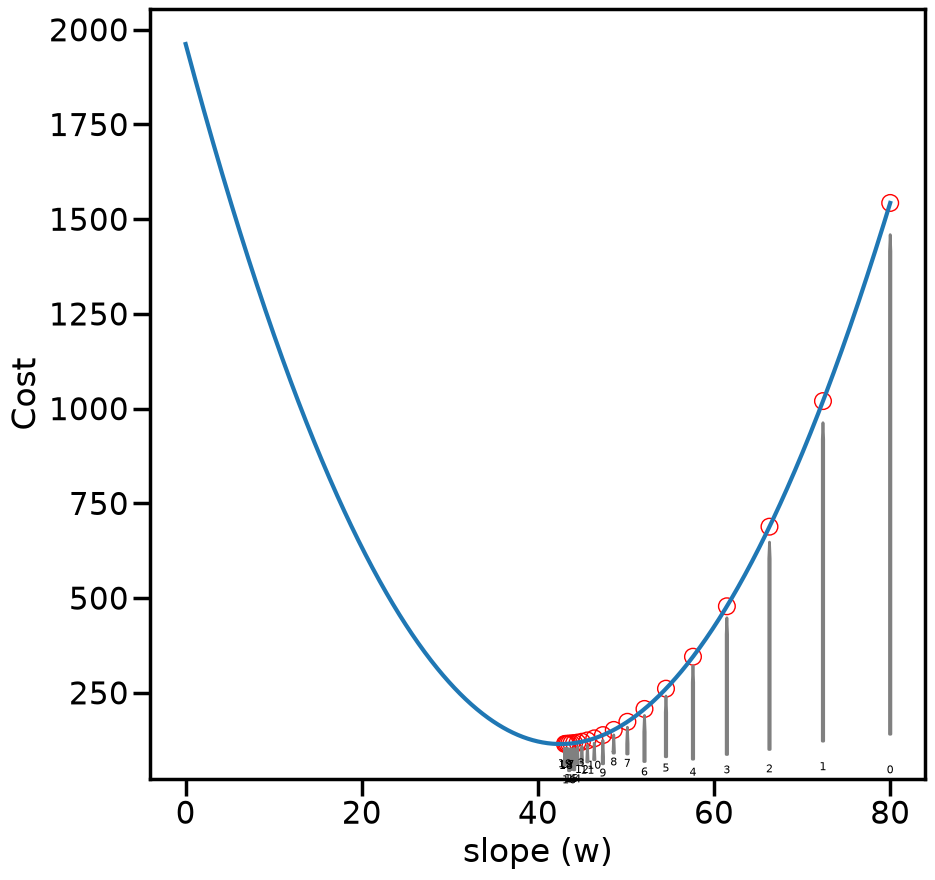

In [10]:
np.random.seed(0)  # the annotation offsets below are random; fix them
weight_cost = [loss(w) for w in weights]
plt.figure(figsize=(10,10))
plt.plot(wp,cost)
plt.scatter(weights,weight_cost,facecolors='none', edgecolors='r',linewidth=1)
ax = plt.gca()
for i,w in enumerate(weights):
    ax.annotate('{}'.format(i), xy=(w, weight_cost[i]-10), 
                xytext=(w+1e-8, 10+50*np.random.rand()),
                ha='center',fontsize=8,
                arrowprops=dict(facecolor='white', edgecolor='grey',
                                shrink=0.05,
                            width=1, headwidth=1)
               )
plt.ylabel('Cost')
plt.xlabel('slope (w)')
plt.show()

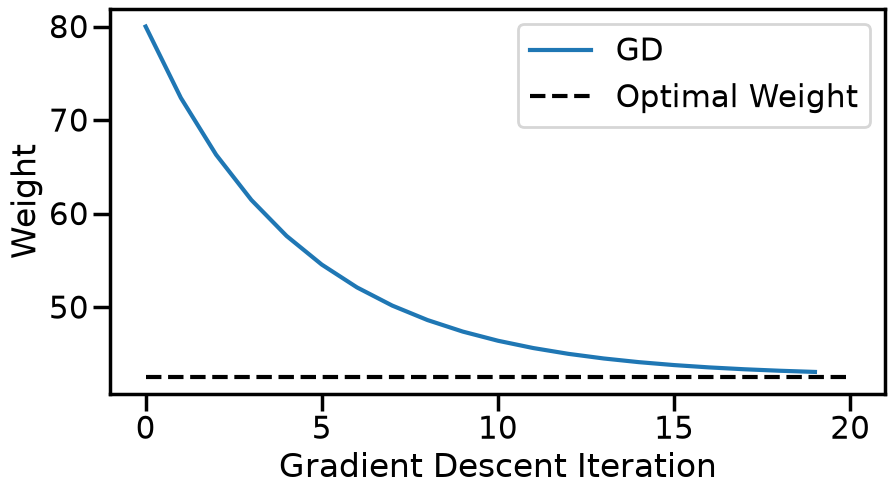

In [11]:
# Plot how the weights progress
plt.figure(figsize=(10,5))
plt.plot(range(len(weights)),weights, label='GD')
plt.hlines(wn, 0, len(weights), 
           label = "Optimal Weight", 
           color='k', linestyle="--")
plt.xlabel('Gradient Descent Iteration')
plt.ylabel('Weight')
plt.legend()
plt.show()
# Copying for comparison later
gd_weights = weights

## How Large Can the Step Size Be?

In the Experiment above you probably found three kinds of behavior. With a small step size, gradient descent creeps towards the optimum. With a moderate one, it gets there quickly. And somewhere a bit below $\alpha = 1$ it suddenly stops working: the weights jump back and forth across the optimum and fly off to infinity. Can we predict where that happens, without trial and error?

We can, and all we need is a Taylor expansion. To do this, instead of tracking the weight $w_t$ itself, we can track its *error*, that is, the distance $e_t = w_t - w^*$ from the optimum $w^*$. Let's look at how this error manifests near the optimum. We'll expand the gradient with a first-order Taylor expansion:

$$
\frac{\partial J}{\partial w}(w) \approx \frac{\partial J}{\partial w}(w^*) + \frac{\partial^2 J}{\partial w^2}(w^*)\,(w - w^*) = \lambda\, e 
$$

where the first term vanishes because the gradient is zero at the optimum, and $\lambda = \partial^2 J / \partial w^2$ is the *curvature* of the cost. For our squared-error cost, the gradient $-\frac{2}{N}\sum_i (y_i - w x_i)\, x_i$ is a straight line in $w$, so this expansion is not an approximation at all: it is exact, with $\lambda = \frac{2}{N}\sum_i x_i^2 = 2\,\overline{x^2}$ everywhere.

Now put the gradient back into the update rule $w_{t+1} = w_t - \alpha\, \partial J / \partial w$ and subtract $w^*$ from both sides:

$$
\begin{aligned}
e_{t+1} &= e_t - \alpha \lambda\, e_t = (1 - \alpha\lambda)\, e_t , \\
e_t &= (1 - \alpha\lambda)^t\, e_0 .
\end{aligned}
$$

Every step multiplies the error by the same number, $1 - \alpha\lambda$, and from this we can diagnose the behavior we saw above:

- If $0 < \alpha < 1/\lambda$, the factor is between 0 and 1: the error shrinks and keeps its sign, so the weights slide smoothly down one side of the valley.
- If $\alpha = 1/\lambda$, the factor is exactly 0: gradient descent lands on the optimum in a single step. This is the *optimal* step size for this problem.
- If $1/\lambda < \alpha < 2/\lambda$, the factor is between $-1$ and 0: every step overshoots to the other side of the valley, but by less than before, so the weights zig-zag inwards.
- If $\alpha > 2/\lambda$, the factor is below $-1$: every step overshoots by *more* than the error it started with, and the zig-zag grows without limit.

So gradient descent converges exactly when $0 < \alpha < 2/\lambda$. The more sharply curved the valley, the smaller the step you can afford: the gradient changes a lot over one step, so a long stride based on the gradient at the start overshoots badly. Let's compute these numbers for our data.

In [12]:
mean_x2 = np.mean(np.asarray(X) ** 2)     # the average of x_i^2 over the data
curvature = 2 * mean_x2                      # lambda, the second derivative of the cost
alpha_optimal = 1 / curvature                # lands on the optimum in one step
alpha_max = 2 / curvature                    # above this, gradient descent diverges

print("Curvature of the cost:        lambda = {:.3f}".format(curvature))
print("Optimal step size:         1/lambda = {:.3f}".format(alpha_optimal))
print("Largest stable step size:  2/lambda = {:.3f}".format(alpha_max))

Curvature of the cost:        lambda = 2.039
Optimal step size:         1/lambda = 0.490
Largest stable step size:  2/lambda = 0.981


The largest stable step size is just below 1, which is where the Experiment above broke down. Let's run gradient descent at a few step sizes on either side of these two values, and compare the error we actually measure with the prediction $|e_t| = |1 - \alpha\lambda|^t\, |e_0|$.

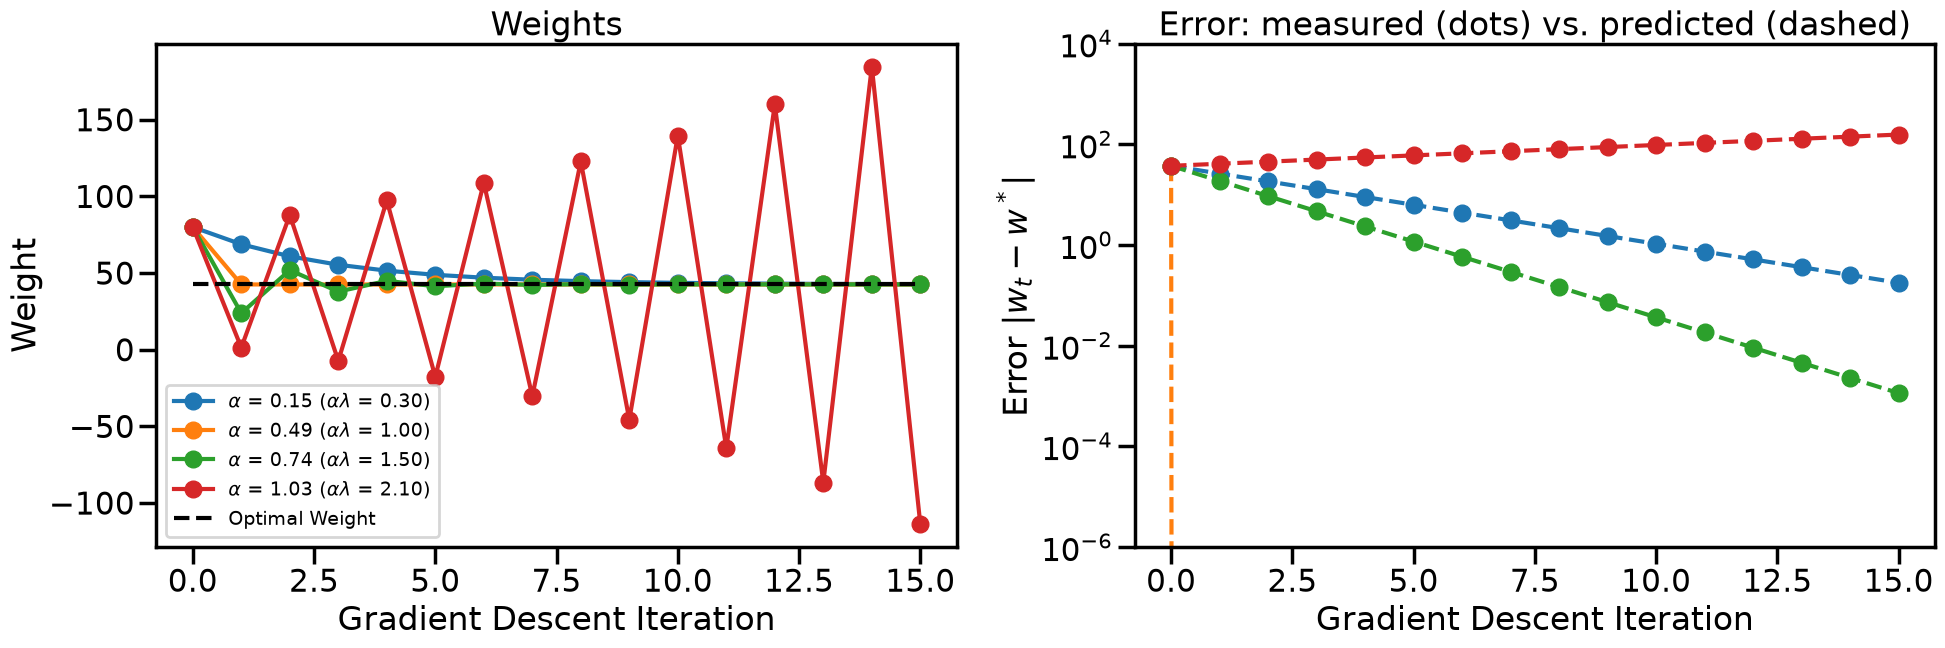

In [13]:
#################################
# Try changing the below
step_sizes = [0.3 * alpha_optimal, alpha_optimal, 1.5 * alpha_optimal, 1.05 * alpha_max]
wg_stability = 80   # initial guess at the slope
n_stability_steps = 15
#################################


def run_gradient_descent(w0, step_size, n_steps):
    # Uses the chapter's grad_step, so this is exactly the gradient descent from the Experiment above
    w_hist = np.zeros(n_steps + 1)
    w_hist[0] = w0
    for t in range(n_steps):
        w_hist[t + 1] = grad_step(w_hist[t], X, step_size)
    return w_hist


fig, (ax_w, ax_err) = plt.subplots(1, 2, figsize=(20, 7))
for i, step in enumerate(step_sizes):
    w_hist = run_gradient_descent(wg_stability, step, n_stability_steps)
    label = r"$\alpha$ = {:.2f} ($\alpha\lambda$ = {:.2f})".format(step, step * curvature)
    ax_w.plot(w_hist, marker='o', color='C{}'.format(i), label=label)
    measured = np.abs(w_hist - wn)
    predicted = np.abs(1 - step * curvature) ** np.arange(n_stability_steps + 1) * abs(wg_stability - wn)
    ax_err.plot(measured, marker='o', linestyle='none', color='C{}'.format(i))
    ax_err.plot(predicted, linestyle='--', color='C{}'.format(i))
ax_w.hlines(wn, 0, n_stability_steps, color='k', linestyle='--', label='Optimal Weight')
ax_w.set_xlabel('Gradient Descent Iteration')
ax_w.set_ylabel('Weight')
ax_w.set_title('Weights')
ax_w.legend(fontsize=14)
ax_err.set_yscale('log')
ax_err.set_ylim(1e-6, 1e4)
ax_err.set_xlabel('Gradient Descent Iteration')
ax_err.set_ylabel(r'Error $|w_t - w^*|$')
ax_err.set_title('Error: measured (dots) vs. predicted (dashed)')
plt.tight_layout()
plt.show()

On the right, the dots sit exactly on the dashed lines: for a quadratic cost the error really is multiplied by $1 - \alpha\lambda$ at every step. On a log scale that makes each run a straight line, whose slope is $\log|1 - \alpha\lambda|$. The optimal step size drops straight to zero error after one step (it falls off the bottom of the plot), and the step just above $2/\lambda$ grows. Notice also that the zig-zagging step size $1.5/\lambda$ (factor $-0.5$) converges *faster* than the small, smooth one (factor $+0.7$): what matters is the size of the factor, not its sign.

::: {.callout-tip appearance="default"}
### Experiment: Predicting the Blow-Up
Change the list `step_sizes` in the cell above and re-run it.

- Go back to the step sizes you tried in the first Experiment. Does $2/\lambda$ explain where your runs started to fail?
- What happens at exactly $\alpha = 2/\lambda$? What does the factor $1 - \alpha\lambda$ tell you to expect, and is that what you see?
- Suppose we had recorded $x$ in millimetres instead of centimetres, so every $x_i$ is ten times larger. What would happen to $\lambda$, and to the largest step size you can use? (We will come back to this in the Normalization section at the end of the chapter.)
:::

Our cost above was a perfect parabola, so the curvature is the same everywhere and the Taylor expansion is exact. Most costs are not parabolas, but if we are close enough to a minima many losses can behave like one with a curvature $\lambda$ equal to the second derivative at its bottom. So $2/\lambda$ still tells you whether gradient descent can settle into that particular minimum, even though far from it the function may behave very differently. When there are many parameters, the second derivative becomes a matrix of second derivatives (the Hessian), and each direction in parameter space has its own curvature. The sharpest direction then limits how large a step you can take, and the flattest direction decides how long you have to wait. We'll see this below in the Normalization section.

::: {.callout-note appearance="default"}
### Aside: Gradient Descent as a Dynamical System
What we just did has a name outside machine learning. The update rule $w_{t+1} = w_t - \alpha\, \nabla J(w_t)$ is a *discrete-time dynamical system*: a rule that takes the current state and produces the next one. Minima of the cost are its *fixed points* (states that the rule maps to themselves, since the gradient is zero there), and asking "does gradient descent converge?" is the same as asking "is this fixed point stable?". Linearizing around the fixed point with a Taylor expansion, as we did above, is the standard way to answer that question in dynamics and control.

This view turns out to be surprisingly productive. If you shrink the step size towards zero, the iterates trace out the solution of an ordinary differential equation, $\dot{w}(t) = -\nabla J(w(t))$, called *gradient flow*, and properties of the optimizer can be read off properties of the ODE. The momentum method we will meet later in this chapter corresponds to a *second-order* ODE: a heavy ball rolling through the cost landscape with friction ([Su, Boyd and Candès, 2016](https://arxiv.org/abs/1503.01243) work this out for a closely related accelerated method). Stochastic gradient descent adds noise to every step, so it behaves like a *stochastic* differential equation: with a constant step size it does not settle at a point, but keeps jittering in a cloud around the minimum whose width grows with the step size ([Mandt, Hoffman and Blei, 2017](https://arxiv.org/abs/1704.04289)). We'll see this manifest in Stochastic Gradient Descent in the next section.
:::

## Stochastic Gradient Descent
To perform Gradient Descent, we needed to sum the gradients across all data points (to compute $\nabla J$). We may not want to do this, for many reasons: 1) we may not be able to iterate through all the data points easily (maybe the data are split across many computers or files), 2) we may not want to store the data at all after we are done with it (online learning), 3) maybe computing the gradient for one data point is difficult, and we would like to make forward progress on the model while computing gradients of other points, *etc.*

This is where *Stochastic* Gradient Descent comes it. Rather than Gradient Descent, which computes the gradient over all the data ($\mathbf{X}$):
$$
\mathbf{w}_{t+1} = \mathbf{w}_t - \alpha \frac{\partial J(\mathbf{w},\mathbf{X})}{\partial \mathbf{w}}
$$

Stochastic Gradient Descent computes a similar quantity, but only over one data point ($\mathbf{x}_i$) at a time (or a small batch of data if that is feasible):
$$
\mathbf{w}_{t+1} = \mathbf{w}_t - \alpha \frac{\partial J(\mathbf{w},\mathbf{x}_i)}{\partial \mathbf{w}}
$$


In [14]:
def sgd_dloss(w,y,x):
    # y is an np.matrix column, so the product is 1x1; .item() pulls out the scalar.
    return float(np.asarray(-2*(y-w*x)*x).item())

In [15]:
#################################
# Try Changing the below
wg = 80 # Initial guess at slope
alpha = 0.05  # Step Size
num_passes = 40  # Number of times we pass through the data
shuffle_after_pass = False  # Whether to shuffle the data
##########################
# What do you find?

np.random.seed(0)  # so that shuffling is reproducible
N = len(y)
weights = np.zeros(N*num_passes+1)
k=0
weights[k] = wg  # Set the initial weight
print('Initial weight: ',weights[0])

index = list(range(N))
for n in range(num_passes):
    if shuffle_after_pass:
        np.random.shuffle(index)
    for i in index:
        k+=1
        xi = X[i,0]
        yi = y[i]
        weights[k] = weights[k-1] - alpha*sgd_dloss(weights[k-1],yi,xi)
print('Final Weight from SGD: {:.2f}'.format(weights[-1]))
print("Compared to {:.2f} (Normal Equations)".format(wn))

Initial weight:  80.0
Final Weight from SGD: 39.27
Compared to 42.57 (Normal Equations)


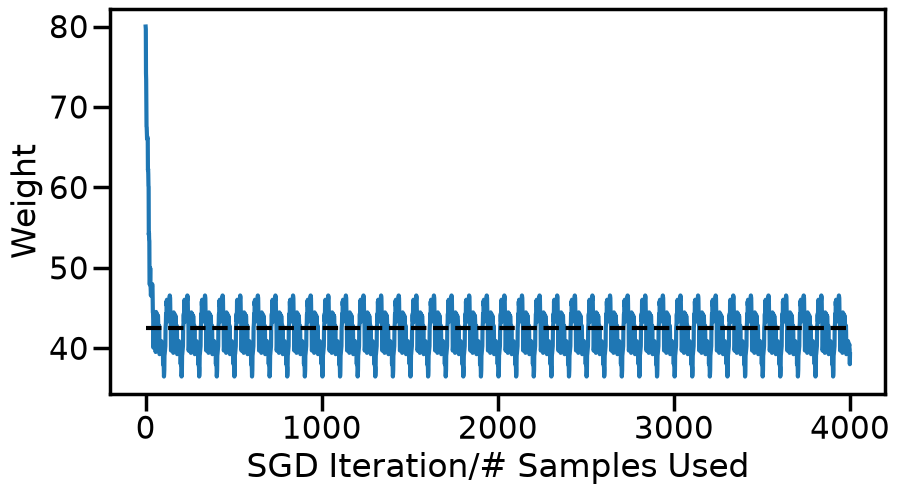

In [16]:
plt.figure(figsize=(10,5))
plt.plot(range(len(weights)),weights)
plt.hlines(wn, 0, len(weights), 
           label = "Optimal Weight", 
           color='k', linestyle="--")
plt.xlabel('SGD Iteration/# Samples Used')
plt.ylabel('Weight')
plt.show()

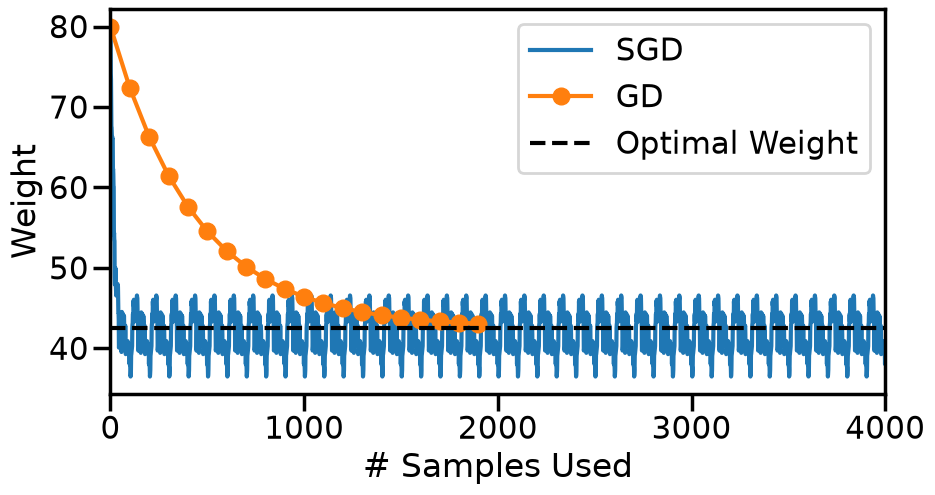

In [17]:
plt.figure(figsize=(10,5))
plt.plot(range(len(weights)), weights,
         label = 'SGD')
plt.plot(np.array(range(len(gd_weights)))*len(index),
         gd_weights,
         marker='o',
         label = 'GD')
plt.hlines(wn, 0, len(weights), 
           label = "Optimal Weight", 
           color='k', linestyle="--")
plt.xlabel('# Samples Used')
plt.ylabel('Weight')
#plt.ylim([30,55])
plt.xlim([0,len(weights)])
plt.legend()
plt.show()

::: {.callout-tip appearance="default"}
### Experiment: The Behaviour of SGD
Go back to the SGD cell above and change the step size and the number of passes.

- What do you notice about the behaviour of SGD compared with gradient descent?
- What happens when `alpha` is small versus large?
- If you keep doing more passes through the data, do you eventually converge? Why or why not?
:::


What you are seeing is a result of [Stochastic Approximation](https://en.wikipedia.org/wiki/Stochastic_approximation) (trying to approximate a gradient of a function using noisy estimates of that gradient (where the noise here comes from evaluating the gradient using only one data point).

This behavior was studied by multiple people in the 1950s and 60s, with one key result coming Herbert Robbins and Sutton Monro, in what is now called the [Robbins-Monro Algorithm](https://en.wikipedia.org/wiki/Stochastic_approximation#Robbins.E2.80.93Monro_algorithm). The central idea is rather than defining a *single* step size, we should let the step size decrease over time. Initially, we need to move the weights a lot, but as we get closer to the goal, they exert less influence so that we *settle* at some point. What they showed was that SGD would converge to the right estimator so long as the sequence satisfies the following properties:


$$
\begin{aligned}
\sum_{n=1}^{\infty} a_n &= \infty \\
\sum_{n=1}^{\infty} a_n^2 &< \infty
\end{aligned}
$$

For sequences where $a_n>0~\forall~n>0$, Robbins and Monro recommended the $a_n = a/n$, however this rate is based on some assumptions about smoothness and convexity which sometimes don't work well in practice. People generally use decay rates on the order of $O(1/\sqrt(n))$,  however there are entire fields of researchers working on this "optimal step size" problem for SGD and there are many great alternative procedures out there if you know certain things about the function (e.g., can compute things like hessians, etc.) 

Initial weight:  80.0
Final Weight from SGD: 42.09
Compared to 42.57 (Normal Equations)


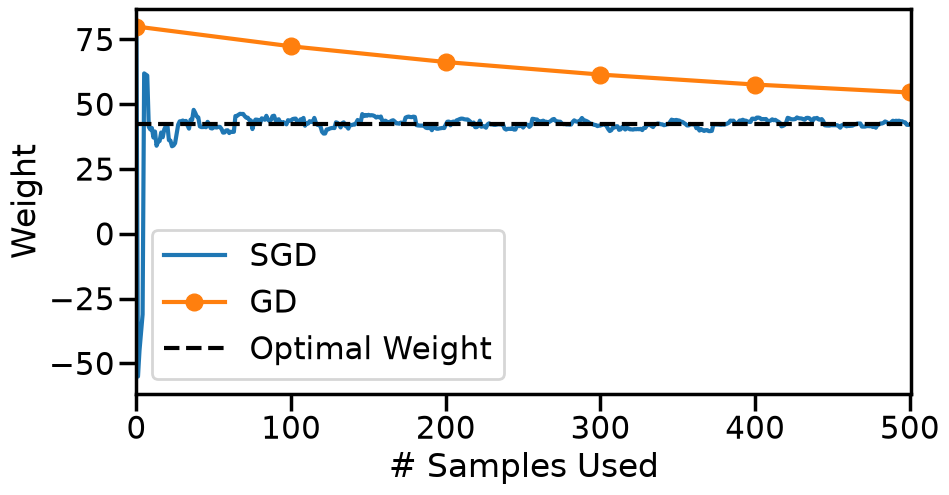

In [18]:
#################################
# Try Changing the below
wg = 80 # Initial guess at slope
alpha_i = 0.5  # Initial Step Size
#alpha = lambda n: alpha_i
#alpha = lambda n: alpha_i/n
alpha = lambda n: alpha_i/np.sqrt(n)
num_passes = 5  # Number of times we pass through the data
shuffle_after_pass = True  # Whether to shuffle the data
##########################
# What do you find?

np.random.seed(0)  # so that shuffling is reproducible
N = len(y)
weights = np.zeros(N*num_passes+1)
k=0
weights[k] = wg  # Set the initial weight
print('Initial weight: ',weights[0])

index = list(range(N))
for n in range(num_passes):
    if shuffle_after_pass:
        np.random.shuffle(index)
    for i in index:
        k+=1
        xi = X[i,0]
        yi = y[i]
        weights[k] = weights[k-1] - alpha(k)*sgd_dloss(weights[k-1],yi,xi)
print('Final Weight from SGD: {:.2f}'.format(weights[-1]))
print("Compared to {:.2f} (Normal Equations)".format(wn))

plt.figure(figsize=(10,5))
# Plot SGD Weights
plt.plot(range(len(weights)), weights,
         marker=None,
         label = 'SGD')
# Plot Grad. Descent Weights
plt.plot(np.array(range(len(gd_weights)))*len(index),
         gd_weights,
         marker='o',
         label = 'GD')
# Plot True Answer
plt.hlines(wn, 0, len(weights), 
           label = "Optimal Weight", 
           color='k', linestyle="--")
plt.xlabel('# Samples Used')
plt.ylabel('Weight')
#plt.ylim([30,55])
plt.xlim([0,len(weights)])
plt.legend()
plt.show()

We see from the above that by reducing the step size over time, this can cause the SGD estimate to eventually converge to a stable answer.

## Existing Implementations
SGD is a fairly simple and popular technique for solving many problems where you can easily express the derivatives of those functions. For certain types of loss function (like the square error/L2 norm we discussed above), many folks have written optimized libraries for just that purpose, such as Scikit-Learn's [SGD functions](http://scikit-learn.org/stable/modules/sgd.html) including [SGDRegressor](http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html#sklearn.linear_model.SGDRegressor).

For reference, the SGD Regressor in ScikitLearn uses an update rule similar to:
$$
\eta^{(t)} = \frac{eta_0}{t^{power_t}}
$$

In [19]:
from sklearn.linear_model import SGDRegressor
sgd = SGDRegressor(loss = 'squared_error',
                   eta0 = 0.01,  # Initial Learning rate/step size
                   power_t = 0.25, # how quickly sould eta decay?
                   max_iter = 100,  # Max # of passes to do over the data?
                   tol = 1e-3,     # Tolerance for change in loss
                   fit_intercept=False # Not worrying about b term in w*x+b
                  )
# Here eta = eta0/(t^power_t) where t is the iteration
X = np.asarray(X)
y = np.array(y).reshape(len(y),) # Reshape y so that scikit doesn't complain
sgd.fit(X,y)
print('Final Weight from SKLearn SGD: {:.2f}'.format(sgd.coef_[0]))
print("Compared to {:.2f} (Normal Equations)".format(wn))

Final Weight from SKLearn SGD: 42.57
Compared to 42.57 (Normal Equations)


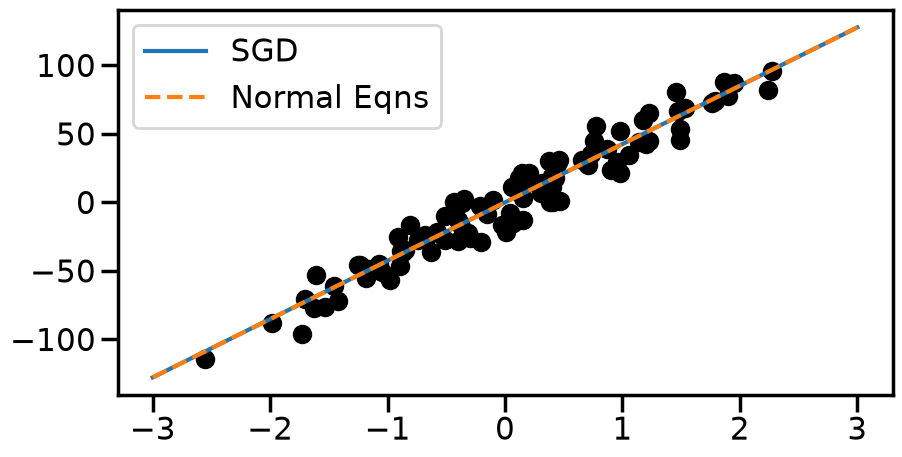

In [20]:
plt.figure(figsize=(10,5))
plt.scatter(np.asarray(X).ravel(),
            np.asarray(y).ravel(),
            color='k'
           )
#plt.scatter(X,y)
Xp = [[-3],[3]]
plt.plot(Xp,sgd.predict(Xp),label='SGD')
plt.plot([-3,3],[-3*wn, 3*wn],
         label='Normal Eqns',
         linestyle='--' )
plt.legend()
plt.show()

## Advanced Techniques

What we presented above was just the "vanilla" version of SGD, and there is an entire sub-field of research focused on more performant variants of this idea. In this section, we'll try to give you a flavor of some of the main variants or tricks people use to accelerate SGD methods,  with the caveat that there are many more interesting rabbit holes you can go down here if you would like in more advanced optimization courses. Most of the popular implementations involve one or more of the following tricks:

1. Using "acceleration" procedures that leverage "momentum" of some type. We'll illustrate this idea below, but you can read much more about this phenomenon (with some nice interactive visualizations) at: ["Why Momentum Really Works"](https://distill.pub/2017/momentum/)
2. "Batching" the SGD updates: that is, taking steps that consider $N>n>1$ data points at a time (for example, averaging the gradients of, say, 5 data points before taking a step). This can help stabilize gradients and improve convergence.
3. "Normalizing" the features or the gradient updates, that is, re-scaling things so that every direction in parameter space is equally easy to walk in. This is commonly used in Neural Networks for things like [Batch Normalization (Wikipedia)](https://en.wikipedia.org/wiki/Batch_normalization) (or, for a more advanced introduction, you can read the NeurIPS paper [Understanding Batch Normalization](https://papers.nips.cc/paper/7996-understanding-batch-normalization.pdf)).

Let's look at each of these on the problem we already have. From here on we work with plain NumPy arrays (the cell above already converted `X` and `y` back from matrices), so we first restate the cost and its gradient in NumPy array form for convenience.

In [21]:
x_arr = X.ravel()          # inputs as a flat array
y_arr = y                  # targets as a flat array
N = len(y_arr)

def mse(w):
    """Mean squared error of the slope-only model y = w * x."""
    return np.mean((y_arr - w * x_arr) ** 2)

def grad_mse(w):
    """Derivative of the mean squared error with respect to the slope w."""
    return -2 * np.mean((y_arr - w * x_arr) * x_arr)

### Momentum

Plain gradient descent forgets everything about the previous step. *Momentum* methods keep a running "velocity" that accumulates past gradients, in the same way a heavy ball rolling down a valley keeps moving in the direction it was already going:

$$
\begin{aligned}
v_{t+1} &= \beta\, v_t + \nabla_w J(w_t) \\
w_{t+1} &= w_t - \alpha\, v_{t+1}
\end{aligned}
$$

With $\beta = 0$ this is exactly gradient descent. As $\beta$ grows towards 1 the ball gets heavier: it picks up speed along directions where the gradient keeps pointing the same way, and it damps out directions where the gradient keeps flipping sign. Let's watch how this change affects the behavior of SGD on our one-parameter problem.

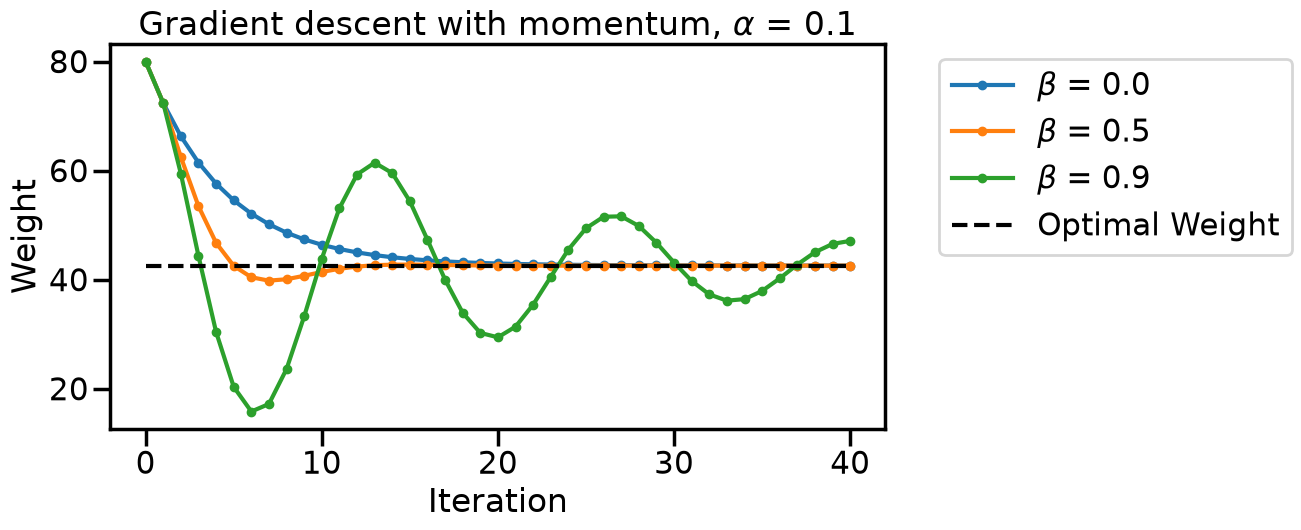

In [22]:
def gradient_descent_momentum(w0, step_size, beta, n_steps):
    """Run heavy-ball gradient descent on the slope problem and return every iterate."""
    w_hist = np.zeros(n_steps + 1)
    w_hist[0] = w0
    velocity = 0.0
    for t in range(n_steps):
        velocity = beta * velocity + grad_mse(w_hist[t])
        w_hist[t + 1] = w_hist[t] - step_size * velocity
    return w_hist



# Try values of step size from ~0.01 to ~0.99 and values of beta from 0.0 to 0.9
momentum_step_size = 0.1
momentum_steps = 40
plt.figure(figsize=(10, 5))
for beta in [0.0, 0.5, 0.9]:
    w_hist = gradient_descent_momentum(80, momentum_step_size, beta, momentum_steps)
    plt.plot(w_hist, marker='.', label=r"$\beta$ = {}".format(beta))
plt.hlines(wn, 0, momentum_steps, label="Optimal Weight", color='k', linestyle="--")
plt.xlabel('Iteration')
plt.ylabel('Weight')
plt.title(r'Gradient descent with momentum, $\alpha$ = {}'.format(momentum_step_size))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

::: {.callout-tip appearance="default"}
### Experiment: How Heavy Should the Ball Be?
Change `momentum_step` and the values of `beta` in the cell above.

- With $\beta = 0.5$ the ball arrives faster than plain gradient descent. With $\beta = 0.9$ it overshoots and oscillates around the optimum before settling. What is it about a heavy ball that produces this behaviour near the bottom of the valley? What about when the step size is really small? What does this behavior remind you of from prior classes you might have taken? 
- Increase the step size until plain gradient descent ($\beta = 0$) starts to diverge (should be somewhere a bit before step size = ~1.0). What does adding momentum make that step size usable again?
:::

::: {.callout-note appearance="default"}
### Aside: Stability with Momentum
Let's redo the stability analysis from *How Large Can the Step Size Be?*, now with momentum. Near the optimum the gradient is still $\lambda\, e_t$, where $e_t = w_t - w^*$ is the error and $\lambda = 2\,\overline{x^2}$ the curvature. In terms of the error, the two momentum updates become

$$
\begin{aligned}
v_{t+1} &= \beta\, v_t + \lambda\, e_t , \\
e_{t+1} &= e_t - \alpha\, v_{t+1} .
\end{aligned}
$$

The second line, one step earlier, says $\alpha\, v_t = e_{t-1} - e_t$, so we can substitute that in for the velocity term:

$$
e_{t+1} = (1 + \beta - \alpha\lambda)\, e_t - \beta\, e_{t-1} .
$$

Alternatively, we can express this as:

$$
e_{t+1} = a\, e_t - \beta\, e_{t-1} .
$$

Where $a=(1 + \beta - \alpha\lambda)$, and we can see that with $\beta = 0$ it collapses back to $e_{t+1} = (1 - \alpha\lambda)\, e_t$. To solve this recurrence equation, we can try the ansatz $e_t = r^t$, which turns the above into a quadratic equation for the per-step factor $r$:

$$
r^{t+1} = a\, r^t - \beta\, r^{t-1} .
$$

and dividing both sides by $r^{t-1}$ gets us:

$$
r^2 - a\, r + \beta = 0 .
$$

This quadratic has two roots, $r_1$ and $r_2$, the error is a mix of $r_1^t$ and $r_2^t$, and gradient descent converges exactly when *both* roots have $|r| < 1$. We can leverage two properties of quadratics to understand this behavior. 
First, via Vieta's formulas, the product of the roots is $r_1 r_2 = \beta$. Second, a real root can only leave the interval $(-1, 1)$ by passing through $r = +1$ or $r = -1$. Substituting those two values into the quadratic shows that this happens at $\alpha\lambda = 0$ and at $\alpha\lambda = 2(1 + \beta)$. So heavy-ball momentum converges exactly when

$$
0 < \alpha < \frac{2(1 + \beta)}{\lambda} .
$$

Two things follow, and both match what you saw in the Experiment above.

- **Momentum widens the stable range.** The largest usable step size grows by a factor $1 + \beta$. For our data, that is $0.98$ for plain gradient descent, $1.47$ with $\beta = 0.5$, and $1.86$ with $\beta = 0.9$. That is why momentum rescued the step sizes at which plain gradient descent diverged. When a step overshoots the valley floor, the velocity still points forward while the new gradient points back, and the two partly cancel.
- **A high $\beta$ can induce oscillation.** With $\beta > 0$, for most step sizes the two roots are a complex pair. Because their product is $\beta$, they then both have size exactly $|r| = \sqrt{\beta}$, no matter what $\alpha$ is. The error spirals in, oscillating around the optimum and shrinking by a factor $\sqrt{\beta}$ per step. With $\beta = 0.5$ that factor is $0.71$, a little better than plain gradient descent's $1 - \alpha\lambda = 0.80$ at our step size of $0.1$. With $\beta = 0.9$ it is $0.95$, so the ball keeps oscillating for a long time before it comes to rest.
:::

### Mini-batching

Gradient descent used all $N$ points per step whereas SGD used one. Everything in between is called a *mini-batch*: you average the gradient over $k$ randomly chosen points, take a step, and move on to the next $k$ points. This batch size $k$ is a dial between the two extremes we have already seen.

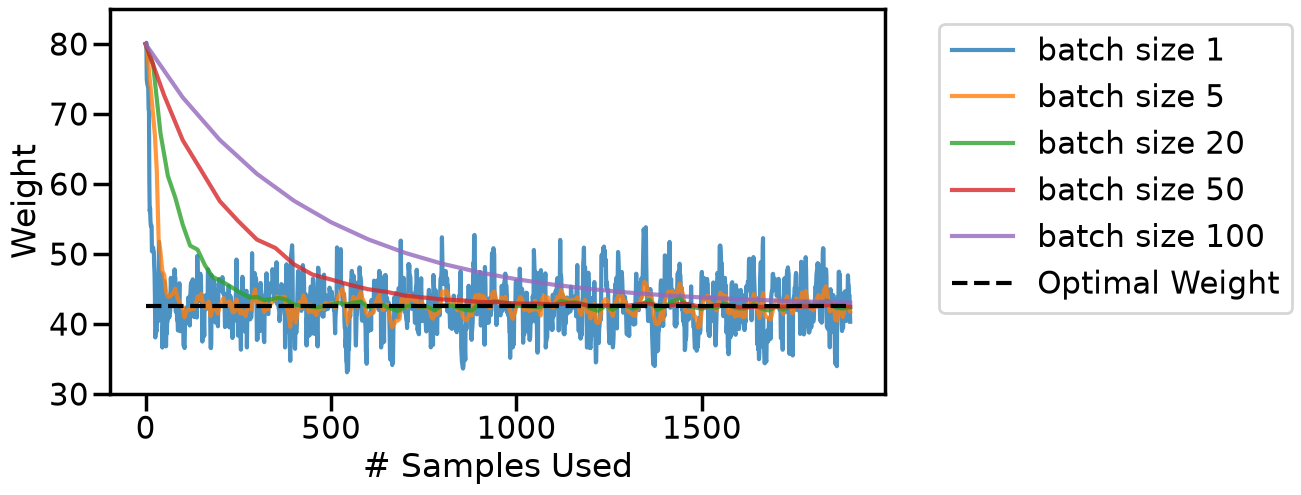

In [24]:
def sgd_minibatch(w0, step_size, batch_size, n_passes, shuffle=False, seed=0):
    """Mini-batch SGD on the slope problem.

    Returns the number of samples used before each recorded weight and the weights themselves.
    With batch_size = N and shuffle = False this is exactly gradient descent.
    """
    rng = np.random.default_rng(seed)
    w = w0
    samples_used = [0]
    w_hist = [w0]
    for _ in range(n_passes):
        order = rng.permutation(N) if shuffle else np.arange(N)
        for start in range(0, N, batch_size):
            batch = order[start:start + batch_size]
            residual = y_arr[batch] - w * x_arr[batch]
            w = w - step_size * (-2 * np.mean(residual * x_arr[batch]))
            samples_used.append(samples_used[-1] + len(batch))
            w_hist.append(w)
    return np.array(samples_used), np.array(w_hist)


batch_passes = len(gd_weights) - 1   # the same number of passes over the data as gradient descent above
plt.figure(figsize=(10, 5))
for batch_size in [1, 5, 20, 50, 100]:
    samples_used, w_hist = sgd_minibatch(80, 0.1, batch_size, batch_passes,
                                         shuffle=True)
    plt.plot(samples_used, w_hist, label="batch size {}".format(batch_size), alpha=0.8)
plt.hlines(wn, 0, batch_passes * N, label="Optimal Weight", color='k', linestyle="--")
plt.xlabel('# Samples Used')
plt.ylabel('Weight')
plt.ylim([30, 85])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

::: {.callout-tip appearance="default"}
### Experiment: Between SGD and Gradient Descent
The batch-size-100 curve is gradient descent itself (100 points per step), while batch size 1 is the SGD from earlier.

- Where does each curve sit between the two extremes, both in how noisy it is and in how many samples it needs to get close to the optimum?
- If each gradient evaluation cost the same regardless of batch size (as it roughly does on a GPU), which batch size would you pick?
:::

### Normalization

So far our problem had a single parameter, so there was only one direction to walk in. Real problems have many, and gradient descent gets into trouble when those directions have very different curvatures. The simplest place to see this is a line *with an intercept*, $y = w x + b$, when the feature $x$ is recorded in units with a very different scale.

Suppose the same data had been logged in a unit that makes the numbers ten times larger (millimetres instead of centimetres, say), and that the target has an offset the model must learn (*i.e.*, the intercept). The cost is now a function of two parameters, $J(w, b)$, and its curvature in the $w$ direction is $2\,\overline{x^2}$ while in the $b$ direction it is just $2$. Scaling $x$ by 10 makes that ratio a hundred; scaling by 1000 (metres to millimetres) makes it a million. Let's look at the loss landscape and at what gradient descent does in it.

In both cases below, we will run vanilla SGD, and the only difference will be that for each feature in the training data we will subtract off the mean and then divide it by the standard deviation: `x_standardized = (x_scaled - x_scaled.mean()) / x_scaled.std()`

In [25]:
# Initial values for the slope and intercept; these are far from the true values
# You can try changing these to see how the optimization behaves
w0 = 20.0
b0 = 5.0

feature_scale = 10.0
x_scaled = x_arr * feature_scale     # the same feature in a unit ten times smaller
b_true = 20.0
y_offset = y_arr + b_true            # a target with an intercept the model must learn


def mse_wb(w, b, x):
    """Mean squared error of the line y = w * x + b on the given inputs."""
    return np.mean((y_offset - (w * x + b)) ** 2)


def grad_mse_wb(w, b, x):
    """Gradient of mse_wb with respect to (w, b)."""
    residual = y_offset - (w * x + b)
    return np.array([-2 * np.mean(residual * x), -2 * np.mean(residual)])


def gradient_descent_wb(x, step_size, n_steps, w0=0.0, b0=0.0):
    """Gradient descent on (w, b) for the line model; returns the path as an (n_steps + 1, 2) array."""
    path = np.zeros((n_steps + 1, 2))
    path[0] = [w0, b0]
    for t in range(n_steps):
        path[t + 1] = path[t] - step_size * grad_mse_wb(path[t, 0], path[t, 1], x)
    return path


def curvatures(x):
    """Curvature of the cost in the w and b directions (the diagonal of its Hessian)."""
    return 2 * np.mean(x ** 2), 2.0


# Standardizing the feature: subtract the mean, divide by the standard deviation
x_standardized = (x_scaled - x_scaled.mean()) / x_scaled.std()

# The largest stable step size is 2 / curvature = 1 / mean(x^2) (see 'How Large Can the Step Size Be?'); use 90% of it
step_raw = 0.9 / np.mean(x_scaled ** 2)
step_std = 0.9 / np.mean(x_standardized ** 2)
path_raw = gradient_descent_wb(x_scaled, step_raw, 300, w0=w0, b0=b0)
path_std = gradient_descent_wb(x_standardized, step_std, 300, w0=w0, b0=b0)

for name, x_used, step in [("raw feature (x 10)", x_scaled, step_raw), ("standardized feature", x_standardized, step_std)]:
    curv_w, curv_b = curvatures(x_used)
    print("{:>22s}: curvature in w = {:8.2f}, in b = {:.2f}, ratio = {:6.1f}, step size used = {:.4f}".format(
        name, curv_w, curv_b, curv_w / curv_b, step))
diverged = gradient_descent_wb(x_scaled, 0.1, 20)[-1, 0]
print("With the old step size of 0.1 on the raw feature, w after 20 steps is {:.1e} (diverged)".format(diverged))

    raw feature (x 10): curvature in w =   203.88, in b = 2.00, ratio =  101.9, step size used = 0.0088
  standardized feature: curvature in w =     2.00, in b = 2.00, ratio =    1.0, step size used = 0.9000
With the old step size of 0.1 on the raw feature, w after 20 steps is -2.5e+26 (diverged)


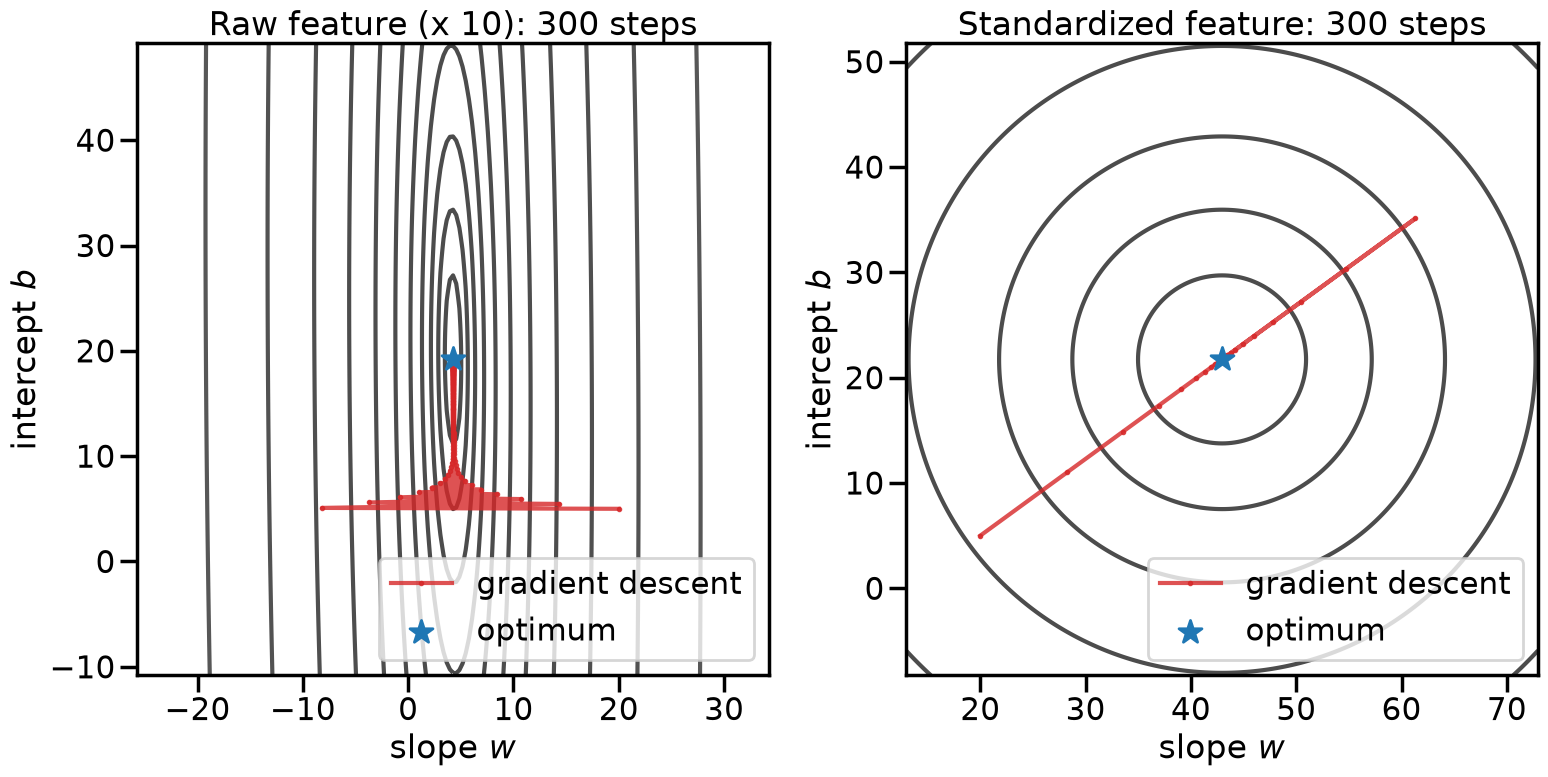

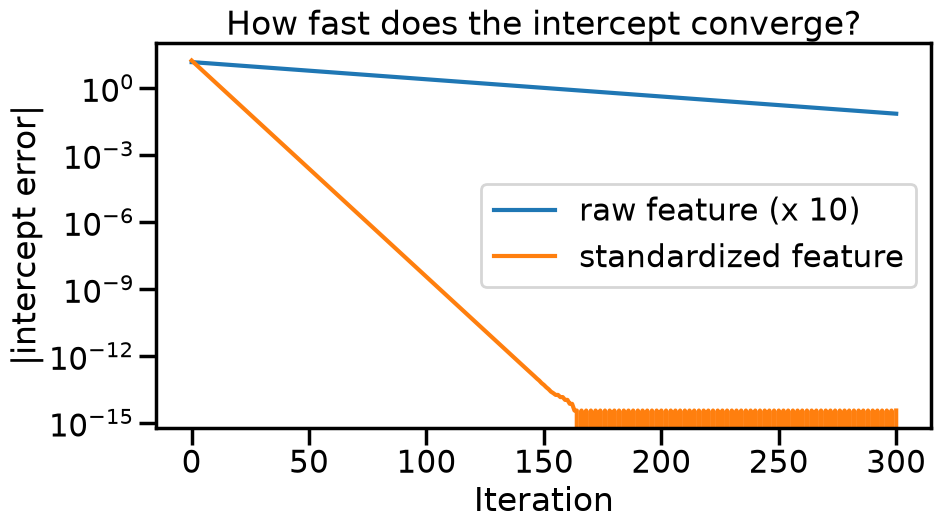

In [26]:
def plot_landscape(ax, x, path, title):
    """Contours of the (w, b) cost for inputs x, the true optimum, and a gradient descent path."""
    # Exact optimum from the normal equations, used to centre the plot
    design = np.column_stack([x, np.ones_like(x)])
    w_opt, b_opt = np.linalg.lstsq(design, y_offset, rcond=None)[0]
    half_width = 30
    w_grid, b_grid = np.meshgrid(np.linspace(w_opt - half_width, w_opt + half_width, 201),
                                 np.linspace(b_opt - half_width, b_opt + half_width, 201))
    cost_grid = np.array([[mse_wb(w, b, x) for w in w_grid[0]] for b in b_grid[:, 0]])
    ax.contour(w_grid, b_grid, cost_grid, levels=np.logspace(2, 6, 17), cmap='Greys_r', alpha=0.7)
    ax.plot(path[:, 0], path[:, 1], 'o-', ms=3, color='C3', alpha=0.8, label='gradient descent')
    ax.scatter([w_opt], [b_opt], marker='*', s=300, color='C0', zorder=5, label='optimum')
    ax.set_xlim(w_opt - half_width, w_opt + half_width)
    ax.set_ylim(b_opt - half_width, b_opt + half_width)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('slope $w$')
    ax.set_ylabel('intercept $b$')
    ax.set_title(title)
    ax.legend(loc='lower right')


fig, axes = plt.subplots(1, 2, figsize=(16, 8))
plot_landscape(axes[0], x_scaled, path_raw, "Raw feature (x 10): 300 steps")
plot_landscape(axes[1], x_standardized, path_std, "Standardized feature: 300 steps")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(np.abs(path_raw[:, 1] - np.linalg.lstsq(np.column_stack([x_scaled, np.ones(N)]), y_offset, rcond=None)[0][1]),
         label='raw feature (x 10)')
plt.plot(np.abs(path_std[:, 1] - np.linalg.lstsq(np.column_stack([x_standardized, np.ones(N)]), y_offset, rcond=None)[0][1]),
         label='standardized feature')
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('|intercept error|')
plt.title('How fast does the intercept converge?')
plt.legend()
plt.show()

On the left the contours are a long narrow valley: the cost changes a hundred times faster along $w$ than along $b$. The largest step size that is stable along $w$ is tiny for $b$, so gradient descent shoots to the correct slope in a few steps and then crawls along the valley floor towards the correct intercept; after 300 steps it is still not there. On the right, after standardizing the feature, the contours are nearly circular, one step size suits both directions, and the same 300 steps land easily on the optimum.

This is why many machine learning pipelines standardize their inputs, and it is the seed of an idea we will meet again with neural networks: *batch normalization* re-standardizes the signals *inside* the network at every layer, for exactly the same reason, so that one learning rate works for all the weights at once. There are also more advanced SGD variants that attempt to learn or rescale features during optimization to account for this automatically.

## Exercises

The exercises below reuse the data and functions from this chapter (`x_arr`, `y_arr`, `wn`, `mse`, `grad_mse`, `gd_weights`, and the momentum and mini-batch functions), so run the chapter's cells first.

::: {.callout-note appearance="simple" icon=false}
### Exercise 1 (~8 min): Common Gradients you will meet again
The chapter derived $\partial J / \partial w$ for the squared error of a slope-only linear model. The same few moves cover almost every loss and penalty you will see in this course. Work these out by hand (a sentence or two of justification each is enough):

- (a) The squared error of a line *with* an intercept, $J(a, b) = \frac{1}{N}\sum_i (y_i - a x_i - b)^2$: find $\partial J/\partial a$ and $\partial J/\partial b$. Consider how you would do this also in the vector form $\mathbf{w}^T \mathbf{x}$.
- (b) The $L_2$ penalty $\Omega(\mathbf{w}) = \alpha\, ||\mathbf{w}||_2^2 = \alpha \sum_j w_j^2$: find $\nabla_\mathbf{w} \Omega$.
- (c) The $L_1$ penalty $\Omega(\mathbf{w}) = \alpha\, ||\mathbf{w}||_1 = \alpha \sum_j |w_j|$: find $\nabla_\mathbf{w} \Omega$ wherever it exists, and say what goes wrong at $w_j = 0$.
- (d) The Huber loss of a single residual $r$, which is $\tfrac{1}{2} r^2$ for $|r| \le \delta$ and $\delta |r| - \tfrac{1}{2}\delta^2$ otherwise: find $dL/dr$ and sketch it.
- (e) The logistic loss of one example, $L = \log\left(1 + e^{-y\, \mathbf{w}^T \mathbf{x}}\right)$ with $y = \pm 1$: find $\nabla_\mathbf{w} L$.
- (f) A bi-linear model of two column vectors $u$ and $v$: $J(u,v) = u^T v$ where you want $\partial J / \partial u$ and $\partial J / \partial v$
- (g) In matrix form, with $\mathbf{X}$ an $N \times d$ matrix: (1) $\nabla_\mathbf{w} ||\mathbf{y} - \mathbf{X}\mathbf{w}||_2^2$, (2) $\nabla_\mathbf{w}\, \mathbf{w}^T \mathbf{A} \mathbf{w}$ for a square matrix $\mathbf{A}$, and (3) $\partial\, ||\mathbf{Y} - \mathbf{X}\mathbf{W}||_F^2 / \partial \mathbf{W}$ for a matrix of weights $\mathbf{W}$ (the Frobenius norm is the square root of the sum of all squared entries). Note: the [Matrix Cookbook](https://www.math.uwaterloo.ca/~hwolkowi/matrixcookbook.pdf) is a good reference for common Matrix operations and derivatives.

You can check (a) numerically: with $b = 0$ your $\partial J/\partial a$ should agree with the chapter's `grad_mse`.
:::

---


::: {.callout-note appearance="simple" icon=false}
### Exercise 2 (~10 min): Chain the pieces together
Real training objectives are sums of the pieces from Exercise 1, and their gradients are sums of the piece gradients. Consider the *elastic net* objective for a line with an intercept,

$$
J(\mathbf{w}) = \frac{1}{N} \sum_i \left(y_i - \mathbf{w}^T \mathbf{x}_i\right)^2 + \alpha\, a^2 + \beta\, |a|,
\qquad \mathbf{x}_i = [x_i, 1],\quad \mathbf{w} = [a, b],
$$

where the penalties act on the slope $a$ only (it is conventional not to penalize the intercept $b$, since shifting all the $y_i$ by a constant should only shift $b$). Use the chapter's data with $\alpha = 0.1$ and $\beta = 5$.

- (a) Write a function `grad_J(w)` that returns the two-component gradient by adding the pieces from Exercise 1.
- (b) Check it against a finite-difference approximation at a random $\mathbf{w}$ (evaluate $J$ at $w_j \pm h$ with $h = 10^{-5}$), or use `scipy.optimize.check_grad`. Avoid $a = 0$ exactly; why?
- (c) Run gradient descent with your gradient from $\mathbf{w}_0 = [80, 0]$ and compare the slope $a$ you reach with `wn`. Which way do the two penalties move it?
- (d) When the weights are large, which of the three terms dominates the gradient? When they are close to zero? What does that suggest about which penalty creates exactly-zero weights?
:::

---


Run the cell below to produce the figure for Exercise 3. It plots a function with more than one valley, together with its derivative.

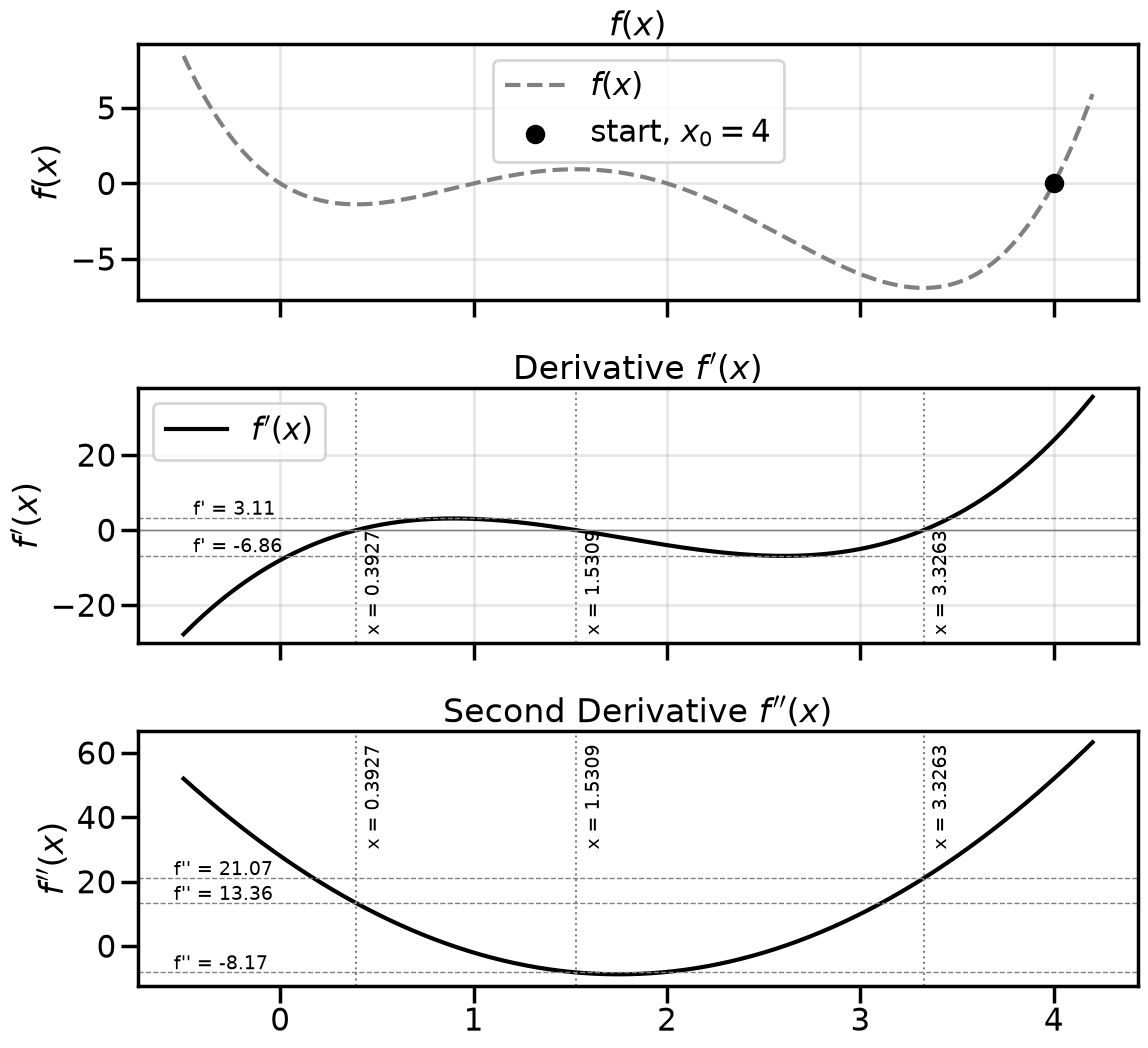

In [27]:
#| echo: false
# Exercise 3 figure: a non-convex quartic and its derivative, with the critical points marked.
def ex3_f(x):
    return x**4 - 7 * x**3 + 14 * x**2 - 8 * x


def ex3_df(x):
    return 4 * x**3 - 21 * x**2 + 28 * x - 8

def ex3_d2f(x):
    return 12 * x**2 - 42 * x + 28

ex3_x = np.linspace(-0.5, 4.2, 400)
ex3_critical = np.sort(np.roots([4, -21, 28, -8]).real)     # where f'(x) = 0
ex3_df_extremes = np.sort(np.roots([12, -42, 28]).real)     # where f''(x) = 0

fig, (ax_f, ax_df,ax_d2f) = plt.subplots(3, 1, figsize=(12, 11), sharex=True)
ax_f.plot(ex3_x, ex3_f(ex3_x), color='grey', linestyle='--', label='$f(x)$')
ax_f.scatter([4.0], [ex3_f(4.0)], color='k', zorder=5, label='start, $x_0 = 4$')
ax_f.set_ylabel('$f(x)$')
ax_f.set_title('$f(x)$')
ax_f.legend(loc='upper center')
ax_f.grid(True, alpha=0.3)

ax_df.plot(ex3_x, ex3_df(ex3_x), color='k', label="$f'(x)$")
ax_df.axhline(0, color='grey', linewidth=1)
for xc in ex3_critical:
    ax_df.axvline(xc, color='grey', linestyle=':', linewidth=1.5)
    ax_df.text(xc + 0.04, -28, 'x = {:.4f}'.format(xc), rotation=90, fontsize=14, va='bottom')
for xe in ex3_df_extremes:
    ax_df.axhline(ex3_df(xe), color='grey', linestyle='--', linewidth=1)
    ax_df.text(-0.45, ex3_df(xe) + 1, "f' = {:.2f}".format(ex3_df(xe)), fontsize=14)
ax_df.set_ylim(-30, 38)

ax_df.set_ylabel("$f'(x)$")
ax_df.set_title("Derivative $f'(x)$")
ax_df.legend(loc='upper left')
ax_df.grid(True, alpha=0.3)

# Add a plot of the second derivative in a new subplot below the first two, with the same x-axis. Mark the curvatures at the minima and maxima of f'(x) with horizontal lines and labels.
ax_d2f.plot(ex3_x, ex3_d2f(ex3_x), color='k', label="$f''(x)$")
for xe in ex3_critical:
    ax_d2f.axvline(xe, color='grey', linestyle=':', linewidth=1.5)
    ax_d2f.text(xe + 0.04, 30, 'x = {:.4f}'.format(xe), rotation=90, fontsize=14, va='bottom')
    ax_d2f.axhline(ex3_d2f(xe), color='grey', linestyle='--', linewidth=1)
    ax_d2f.text(-0.55, ex3_d2f(xe) + 1, "f'' = {:.2f}".format(ex3_d2f(xe)), fontsize=14)
#ax_d2f.set_ylim(-10, 50)
ax_d2f.set_ylabel("$f''(x)$")
ax_d2f.set_title("Second Derivative $f''(x)$")  


plt.tight_layout()
plt.show()





::: {.callout-note appearance="simple" icon=false}
### Exercise 3 (~8 min): Where does gradient descent end up?
Every cost in this chapter so far has been convex: one valley, one bottom, so gradient descent cannot end up anywhere else. The function in the figure above is not convex:

$$
f(x) = x^4 - 7x^3 + 14x^2 - 8x, \qquad f'(x) = 4x^3 - 21x^2 + 28x - 8 .
$$

We run gradient descent with a fixed step size, starting at $x_0 = 4.0$, where $f(4) = 0$ and $f'(4) = 24$. Consider four step sizes: A: $\alpha = 0.025$, B: $\alpha = 0.10$, C: $\alpha = 0.15$ and D: $\alpha = 0.2$.

- (a) Without running any code, predict for each step size where gradient descent ends up if we keep iterating: near which point on the $x$-axis, or does it diverge? Does it converge? Why? You should only need one gradient descent step by hand per step size, and then some reasoning with the plots and what you know about how gradient descent works.
- (b) Now check your predictions: run gradient descent for each step size (implement this however you like) and plot $x_t$ against the iteration $t$. Where did your predictions hold, and where did the runs surprise you? Why?
:::

---


::: {.callout-note appearance="simple" icon=false}
### Exercise 4 (~4 min): Does the schedule qualify?
Four colleagues propose step-size schedules for SGD, each with a constant $a > 0$: (i) $a_n = a / n$, (ii) $a_n = a / \sqrt{n}$, (iii) $a_n = a$, (iv) $a_n = a / n^2$.

- (a) For each, decide whether it satisfies the two Robbins-Monro conditions $\sum a_n = \infty$ and $\sum a_n^2 < \infty$, and name the condition that fails when one does.
- (b) Only one schedule passes both tests, yet the chapter says people generally use $1/\sqrt{n}$ in practice. What does each failing condition cost you in practice, and why might that be an acceptable price?
:::

---


::: {.callout-note appearance="simple" icon=false}
### Exercise 5 (~6 min): Match the library
The chapter's decaying-step SGD (initial step 0.5, step $0.5/\sqrt{k}$ at update $k$, five shuffled passes, no penalty, no intercept) can be reproduced with `SGDRegressor`.

- (a) Which values of `learning_rate`, `eta0`, `power_t`, `max_iter`, `penalty`, `fit_intercept` and `tol` correspond to the hand-written loop? Fit it on `X, y` with `random_state=0` and compare `coef_` with `wn` and with the hand-coded result.
- (b) Now drop the arguments one at a time and go back to the defaults. Which default changes the answer most, and why? (Look up what `penalty`, `alpha`, `max_iter` and `tol` default to.)
:::

---


::: {.callout-note appearance="simple" icon=false}
### Exercise 6 (~12 min): Tune the learning rate automatically (take-home)
Choosing $\alpha$ by hand is what we did in the Experiments. The previous chapter gave us tools to do it automatically. Define the black-box objective

$$
f(\alpha) = \log_{10} J\!\left(w_{15}(\alpha)\right),
$$

the (log) cost after 15 steps of gradient descent from $w_0 = 80$ with step size $\alpha \in (0.01, 1.5)$.

- (a) Plot $f(\alpha)$ on a fine grid first, so you know what the two methods below are looking for. Where is the minimum, and where does gradient descent start to diverge? Compare with what you saw in the first Experiment.
- (b) *Random search*: draw 15 values of $\alpha$ from a distribution you consider sensible for a step size and report the best one.
- (c) *Bayesian optimization*: starting from three evaluations, fit the Gaussian process from the previous chapter to $f$ and pick the next $\alpha$ by minimizing the lower confidence bound $\mu(\alpha) - 1.96\,\sigma(\alpha)$, for 12 iterations. Report the best $\alpha$ found and compare with random search at the same budget of 15 evaluations.
- (d) Extension: repeat with two hyperparameters, step size and momentum $\beta$, using `gradient_descent_momentum`. Plot the objective over the $(\alpha, \beta)$ plane. How does the best step size depend on $\beta$, and does that agree with what you saw in the momentum Experiment and the *Stability with Momentum* aside after it?
:::

